## 1. Importación de librerías y carga del dataset limpio
Cargamos las librerías necesarias para el modelo (scikit-learn)
y el dataset limpio generado en el EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('dataset_limpio_dashboard1.csv')
print(df.shape)
df.columns

(3353, 11)


Index(['type', 'title', 'country', 'date_added', 'release_year', 'rating',
       'duration', 'listed_in', 'anio_agregado', 'plataforma',
       'clasificacion_edad'],
      dtype='str')

**Conclusiones:**
- Dataset cargado correctamente: 3.353 filas y 11 columnas
- Las columnas disponibles son las generadas en el EDA:
  type, title, country, date_added, release_year, rating, duration,
  listed_in, anio_agregado, plataforma, clasificacion_edad
- Variable objetivo para el modelo: clasificacion_edad (3 clases)
- Variables predictoras candidatas: type, release_year, anio_agregado, plataforma

## 2. Selección de variables predictoras (X) y objetivo (y)
Definimos X (variables que usará el modelo para predecir) e y
(clasificacion_edad, la variable objetivo).
Las variables de texto como title, country o listed_in no se pueden
usar directamente en el modelo, necesitan ser numéricas.

In [2]:
# Encoding de variables categóricas
df['type_cod'] = df['type'].map({'Movie': 0, 'TV Show': 1})
df['plataforma_cod'] = df['plataforma'].map({'Netflix': 0, 'Disney+': 1})
df['edad_cod'] = df['clasificacion_edad'].map({
    'Todos los públicos (0+)': 0,
    'Mayores de 7 años': 1,
    'Familiar (supervisión recomendada)': 2
})

X = df[['type_cod', 'release_year', 'anio_agregado', 'plataforma_cod']]
y = df['edad_cod']

print('X shape:', X.shape)
print('y shape:', y.shape)
print()
print('Distribución de clases:')
print(y.value_counts())

X shape: (3353, 4)
y shape: (3353,)

Distribución de clases:
edad_cod
2    2223
0     649
1     481
Name: count, dtype: int64


**Conclusiones:**
- X contiene 4 variables predictoras: tipo de contenido, año de estreno,
  año de incorporación a la plataforma y plataforma
- y contiene la variable objetivo (clasificacion_edad) codificada en 3 clases:
    - 0: Todos los públicos (0+) → 649 títulos (19.4%)
    - 1: Mayores de 7 años → 481 títulos (14.3%)
    - 2: Familiar (supervisión recomendada) → 2.223 títulos (66.3%)
- Las clases están desbalanceadas: la clase 2 representa el 66% del total,
  igual que ocurría con sii=0 en el dataset de salud. Tendremos esto en
  cuenta al entrenar el modelo usando class_weight='balanced'
- Se excluyeron title, country, listed_in y date_added por ser texto
  y no ser directamente utilizables por el modelo

## 3. División en conjuntos de entrenamiento y prueba
Dividimos los datos: 80% para entrenar el modelo (train) y 20%
para evaluarlo con datos que no ha visto (test). Usamos stratify=y
para mantener la misma proporción de clases en ambos conjuntos.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '/ Test:', X_test.shape)

Train: (2682, 4) / Test: (671, 4)


**Conclusiones:**
- Train: 2.682 filas (80%), Test: 671 filas (20%)
- stratify=y asegura que ambos conjuntos mantienen la misma proporción
  de cada clasificación de edad (0, 1, 2) que el dataset completo
  (~19%, ~14%, ~66% respectivamente)
- random_state=42 garantiza que la división es reproducible
- Listos para entrenar el modelo

## 4. Entrenamiento del modelo Random Forest
Entrenamos un Random Forest Classifier con class_weight='balanced'
para compensar el desbalance de clases (66% son clase 2).

In [4]:
modelo = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

modelo.fit(X_train, y_train)

print('Modelo entrenado')

Modelo entrenado


**Conclusiones:**
- Modelo Random Forest entrenado correctamente con 100 árboles
  y ajuste por desbalance de clases (class_weight='balanced')
- El modelo ha aprendido patrones a partir de 2.682 títulos de entrenamiento,
  usando tipo de contenido, año de estreno, año de incorporación y plataforma
  para predecir la clasificación de edad
- Siguiente paso: evaluar qué tan bien predice usando los 671 casos
  de test que el modelo no ha visto durante el entrenamiento

## 5. Evaluación del modelo: predicciones y accuracy
Usamos el modelo entrenado para predecir la clasificación de edad
sobre el conjunto de test y calculamos el accuracy general.

In [5]:
y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy, 4))

Accuracy: 0.5231


**Conclusiones:**
- El modelo predice correctamente la clasificación de edad en el 52.31%
  de los casos de test (671 casos)
- Para interpretar esto correctamente: si el modelo predijera siempre
  "clase 2" (la clase mayoritaria, ~66% del dataset), tendría un accuracy
  de ~66% SIN aprender nada útil
- Por tanto, un accuracy de 52.31% es menor que ese "baseline tonto",
  lo que indica que el modelo tiene dificultades con solo 4 variables
- Esto es esperable: el tipo de contenido, el año y la plataforma
  no determinan completamente la clasificación de edad, hay mucha
  variabilidad dentro de cada combinación de variables
- Necesitamos mirar la matriz de confusión y el classification report
  para entender mejor dónde acierta y dónde falla el modelo

## 6. Matriz de confusión
Visualizamos la matriz de confusión: en las filas el valor real
de clasificacion_edad, en las columnas lo que predijo el modelo.
La diagonal son aciertos, fuera de ella son errores.

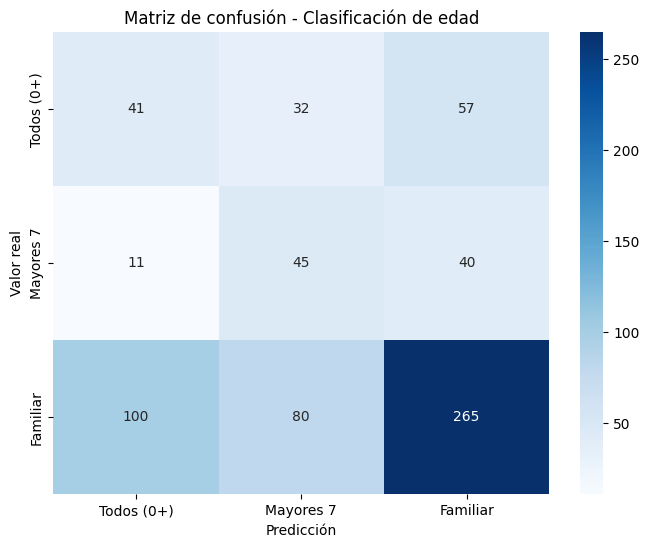

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Todos (0+)', 'Mayores 7', 'Familiar'],
            yticklabels=['Todos (0+)', 'Mayores 7', 'Familiar'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Clasificación de edad')
plt.show()

**Conclusiones:**
- Clase 0 - Todos los públicos (0+), 130 casos reales): el modelo acierta
  41 (31.5%), confunde 32 con Mayores de 7 y 57 con Familiar → es la clase
  más difícil de predecir, el modelo tiende a clasificarla como Familiar
- Clase 1 - Mayores de 7 años (96 casos reales): el modelo acierta
  45 (46.9%), confunde 11 con Todos los públicos y 40 con Familiar
  → rendimiento moderado, también sufre confusión con Familiar
- Clase 2 - Familiar (445 casos reales): el modelo acierta 265 (59.6%),
  confunde 100 con Todos los públicos y 80 con Mayores de 7
  → es la clase mejor predicha por ser la mayoritaria
- Patrón general: el modelo tiende a confundir todas las clases con
  "Familiar" porque es la clase dominante (66% del dataset)
- Los errores son entre clases adyacentes, nunca extremos,
  lo que indica que el modelo capta cierta lógica en los datos

## 7. Classification report
Obtenemos métricas detalladas por clase: precision, recall y f1-score.

In [7]:
print(classification_report(y_test, y_pred,
      target_names=['Todos (0+)', 'Mayores de 7', 'Familiar']))

              precision    recall  f1-score   support

  Todos (0+)       0.27      0.32      0.29       130
Mayores de 7       0.29      0.47      0.36        96
    Familiar       0.73      0.60      0.66       445

    accuracy                           0.52       671
   macro avg       0.43      0.46      0.43       671
weighted avg       0.58      0.52      0.54       671



**Conclusiones:**
- Clase 0 - Todos los públicos (0+): precision=0.27, recall=0.32, f1=0.29
  → el modelo tiene dificultades con esta clase, solo detecta 1 de cada 3
  casos reales y cuando predice "Todos los públicos" se equivoca el 73%
- Clase 1 - Mayores de 7 años: precision=0.29, recall=0.47, f1=0.36
  → rendimiento moderado, detecta casi la mitad de los casos reales
  pero con muchos falsos positivos
- Clase 2 - Familiar: precision=0.73, recall=0.60, f1=0.66
  → es la clase mejor predicha con diferencia, cuando el modelo dice
  "Familiar" acierta el 73% de las veces
- Macro avg (0.43) vs Weighted avg (0.58): la diferencia refleja el
  desbalance, el promedio weighted está dominado por la clase Familiar
  (445 de 671 casos)
- Conclusión honesta: el modelo funciona razonablemente para identificar
  contenido "Familiar" pero tiene dificultades con las clases minoritarias
  (Todos los públicos y Mayores de 7), principalmente porque las 4 variables
  disponibles no capturan toda la complejidad de la clasificación de edad

## 8. Importancia de las variables (feature importance)
Visualizamos qué variables tienen más peso en las decisiones
del modelo para responder: ¿qué factores determinan más
la clasificación de edad del contenido infantil?

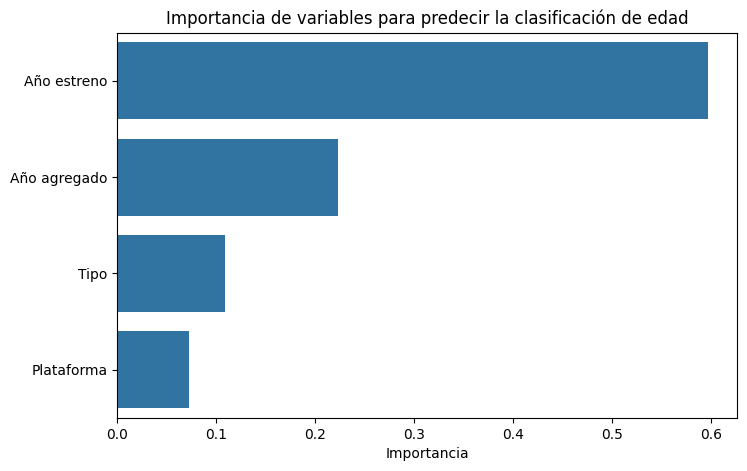

In [10]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=['Tipo', 'Año estreno', 'Año agregado', 'Plataforma']
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title('Importancia de variables para predecir la clasificación de edad')
plt.xlabel('Importancia')
plt.ylabel('')
plt.show()

**Conclusiones:**
- Ranking de importancia de variables para predecir la clasificación de edad:
    1. Año de estreno (~0.60): la variable MÁS importante con diferencia
    2. Año de agregado a la plataforma (~0.22)
    3. Tipo de contenido (Movie/TV Show) (~0.11)
    4. Plataforma (Netflix/Disney+) (~0.07)
- Hallazgo principal: el año de estreno es el predictor dominante,
  lo que tiene sentido: los estándares de clasificación de edad han
  evolucionado con el tiempo, el contenido antiguo tiende a tener
  ratings más permisivos (G, TV-G) mientras que el reciente
  usa clasificaciones más detalladas (TV-PG, TV-Y7)
- La plataforma es la variable menos importante, lo que indica que
  Netflix y Disney+ aplican criterios de clasificación similares
  para su contenido infantil
- Para el Dashboard 1: este resultado sugiere que la época de producción
  determina más la clasificación de edad que la plataforma en sí misma

## 📌 Conclusiones generales del Modelo ML — Dashboard 1

### Objetivo
Predecir la clasificación de edad del contenido infantil
(Todos los públicos / Mayores de 7 / Familiar con supervisión)
a partir de características del título: tipo, año de estreno,
año de incorporación a la plataforma y plataforma.

### Modelo elegido
Random Forest Classifier (100 árboles, class_weight='balanced'
para compensar el desbalance: 66% de los títulos son "Familiar").

### Resultados
- Accuracy general: 52.31%
- El modelo funciona mejor con la clase "Familiar" (f1=0.66)
  por ser la mayoritaria
- Tiene más dificultades con "Todos los públicos" (f1=0.29)
  y "Mayores de 7" (f1=0.36) por ser clases minoritarias
- Los errores son siempre entre clases adyacentes, nunca extremos

### Hallazgo principal: importancia de variables
1. Año de estreno (~60%) — el predictor MÁS importante
2. Año de agregado a la plataforma (~22%)
3. Tipo de contenido (~11%)
4. Plataforma (~7%) — la menos importante

### Implicación para el proyecto
El año de producción determina más la clasificación de edad
que la plataforma. Los estándares de clasificación han evolucionado
con el tiempo, lo que conecta directamente con la narrativa del
Dashboard 1: la evolución del contenido infantil en streaming
no es solo en cantidad sino también en cómo se clasifica y regula.

### Limitaciones
- Solo 4 variables numéricas disponibles: los géneros (listed_in)
  y el país aportarían mucho más poder predictivo pero requieren
  técnicas de procesamiento de texto más avanzadas
- Clases desbalanceadas: la clase "Familiar" domina el dataset
  dificultando la predicción de las clases minoritarias

### Producto final
Modelo entrenado, evaluado e interpretado, listo para incluir
en la memoria como demostración de técnicas de ML aplicadas
al análisis de contenido infantil en streaming.